# Titanic-Datensatz

## Laden der einzelnen Datensätze

In [200]:
import pandas as pd
import numpy as np

In [201]:
titanic_part1_df = pd.read_csv('titanic.csv')
titanic_part1_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [202]:
titanic_part2_incomplete_df = pd.read_csv('titanic_part2_incomplete.csv')
titanic_part2_incomplete_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,951,1,"Chaudanson, Miss. Victorine",female,36.0,0,0,PC 17608,262.3750,B61,C
1,952,3,"Dika, Mr. Mirko",male,17.0,0,0,349232,7.8958,NaN,S
2,953,2,"McCrae, Mr. Arthur Gordon",male,32.0,0,0,237216,13.5000,NaN,S
3,954,3,"Bjorklund, Mr. Ernst Herbert",male,18.0,0,0,347090,7.7500,NaN,S
4,955,3,"Bradley, Miss. Bridget Delia",female,22.0,0,0,334914,7.7250,NaN,Q


In [203]:
titanic_part2_survival_df = pd.read_csv('titanic_part2_survival.csv')
titanic_part2_survival_df.head()

,PassengerId,Survived
0,951,0
1,952,0
2,953,0
3,954,0
4,955,0


## Mergen der unvollständigen Daten

In [204]:
titanic_part2_df = pd.merge(titanic_part2_incomplete_df, titanic_part2_survival_df, how='inner', on='PassengerId')
titanic_part2_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,951,1,"Chaudanson, Miss. Victorine",female,36.0,0,0,PC 17608,262.3750,B61,C,0
1,952,3,"Dika, Mr. Mirko",male,17.0,0,0,349232,7.8958,NaN,S,0
2,953,2,"McCrae, Mr. Arthur Gordon",male,32.0,0,0,237216,13.5000,NaN,S,0
3,954,3,"Bjorklund, Mr. Ernst Herbert",male,18.0,0,0,347090,7.7500,NaN,S,0
4,955,3,"Bradley, Miss. Bridget Delia",female,22.0,0,0,334914,7.7250,NaN,Q,0


## Erzeugen des Gesamtdatensatzes

In [205]:
df = pd.concat([titanic_part1_df, titanic_part2_df], ignore_index=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1303,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1304,1306,0,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1305,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1306,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [206]:
df.to_json('titanic.json', orient='records', indent=2)

## ToDo

1. Datenexploration
1. Cleanup

## Exploration

In [207]:
df.shape

(1308, 12)

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1308 non-null   int64  
 1   Survived     1308 non-null   int64  
 2   Pclass       1308 non-null   int64  
 3   Name         1308 non-null   object 
 4   Sex          1308 non-null   object 
 5   Age          1045 non-null   float64
 6   SibSp        1308 non-null   int64  
 7   Parch        1308 non-null   int64  
 8   Ticket       1308 non-null   object 
 9   Fare         1307 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1306 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


### Fachliche Bedeutung der Spalten

* PassengerId
    * eindeutige Nummer
* Survived
    * 0 -> Died, 1 -> Survived
* PClass
    * Passenger Class, 1 - 4. Klasse
* Name
* Sex
    * male, female
* Age
* SibSp
    * Anzahl der Verwandten (=Siblings) bzs. PartnerInnen (Spouse)
* Parch
    * Parents und Children
* Ticket
    * Eindeutige Ticketnummer, die zur Kontrolle verwendet wurde, ein Zufallswert
* Fare
    * Ticketpreis
* Cabin
    * Nummer der Kabine an Bord
* Embarked
    * 3 Zustiegspunkt, S (= Souuthhampton) Q (=Queenstown), C (=Cherbourg)

### Identifikation von Kategorien

In [209]:
df.nunique()

PassengerId    1308
Survived          2
Pclass            3
Name           1306
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          928
Fare            281
Cabin           186
Embarked          3
dtype: int64

In [210]:
categories_candidates = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
for candidate in categories_candidates:
    print(f'Number of values in candidate {candidate}: {df[candidate].nunique()}, unique values={df[candidate].unique()}')

Number of values in candidate Survived: 2, unique values=[0 1]
Number of values in candidate Pclass: 3, unique values=[3 1 2]
Number of values in candidate Sex: 2, unique values=['male' 'female']
Number of values in candidate SibSp: 7, unique values=[1 0 3 4 2 5 8]
Number of values in candidate Parch: 8, unique values=[0 1 2 5 3 4 6 9]
Number of values in candidate Embarked: 3, unique values=['S' 'C' 'Q' nan]


### Cleanup

* Ideen
  * Nicht-gesetztes Alter
    * drop -> damit sind etwa 20% der Daten weg, eher nicht
    * das Alter wird auf das Durchschnittsalter der Passagiere gesetzt, noch besser: getrennt nach Geschlecht
  * PassengerId ist eigentlich der bessere Index
  * Ticket-Nummer hat keinerlei Aussagekraft, kann komplett entfernt werden
  * Genaueres Anschauen der Cabin führt zur der Erkenntnis, dass der Anfangsbuchstabe dem Bereich an Bord der Titanic entspricht -> Hinzufügen einer neuen Spalte, die nur aus dem Anfangsbuchstaben der Cabin besteht

In [211]:
df['Cabin']

0        NaN
1        C85
2        NaN
3       C123
4        NaN
        ... 
1303     NaN
1304    C105
1305     NaN
1306     NaN
1307     NaN
Name: Cabin, Length: 1308, dtype: object

In [212]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

* Index

In [213]:
df.set_index('PassengerId', inplace=True)

* Ticket entfernen

In [214]:
df.drop('Ticket', axis=1, inplace=True)

* Nicht gesetztes Alter

In [215]:
male_average_age = int(df[df['Sex'] == 'male']['Age'].mean())
female_average_age = int(df[df['Sex'] == 'female']['Age'].mean())
print(male_average_age, female_average_age)
df.loc[(df['Age'].isna()) & (df['Sex'] == 'male'), 'Age'] = male_average_age
df.loc[(df['Age'].isna()) & (df['Sex'] == 'female'), 'Age'] = female_average_age
df.info()


30 28
<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1308 non-null   int64  
 1   Pclass    1308 non-null   int64  
 2   Name      1308 non-null   object 
 3   Sex       1308 non-null   object 
 4   Age       1308 non-null   float64
 5   SibSp     1308 non-null   int64  
 6   Parch     1308 non-null   int64  
 7   Fare      1307 non-null   float64
 8   Cabin     295 non-null    object 
 9   Embarked  1306 non-null   object 
dtypes: float64(2), int64(4), object(4)
memory usage: 112.4+ KB


* Cabin

In [216]:
if 'Cabin' in df.columns:
    df['ShipArea'] = df['Cabin'].astype(str).str[0]
    df.loc[df['ShipArea'] == 'n', 'ShipArea'] = 'unknown'
    df.drop('Cabin', axis=1, inplace = True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,ShipArea
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,unknown
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,unknown
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,C
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,unknown


In [217]:
categories_candidates.append('ShipArea')
for category in categories_candidates:
    df[category] = pd.Categorical(df[category])
df.info()    

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  1308 non-null   category
 1   Pclass    1308 non-null   category
 2   Name      1308 non-null   object  
 3   Sex       1308 non-null   category
 4   Age       1308 non-null   float64 
 5   SibSp     1308 non-null   category
 6   Parch     1308 non-null   category
 7   Fare      1307 non-null   float64 
 8   Embarked  1306 non-null   category
 9   ShipArea  1308 non-null   category
dtypes: category(7), float64(2), object(1)
memory usage: 51.4+ KB


## Analyse

### Deskriptive Statistik

In [218]:
df.describe()

,Age,Fare
count,1308.000000,1307.000000
mean,29.784151,33.315024
std,12.895891,51.773651
min,0.170000,0.000000
25%,22.000000,7.895800
50%,30.000000,14.454200
75%,35.000000,31.275000
max,80.000000,512.329200


In [221]:
print(df['Age'].median())
print(df['Age'].mean())
print(df['Age'].mode())



30.0
29.784151376146788
0    30.0
Name: Age, dtype: float64


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

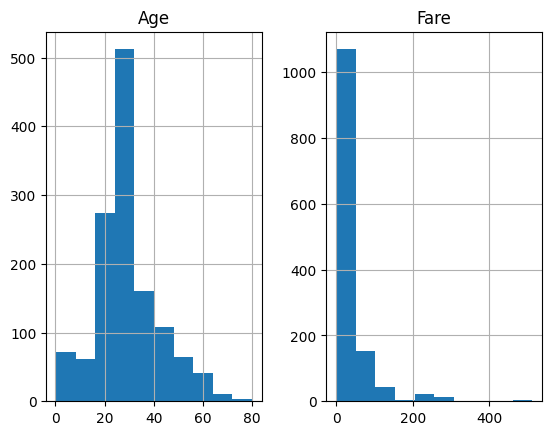

In [222]:
df.hist()

<Axes: >

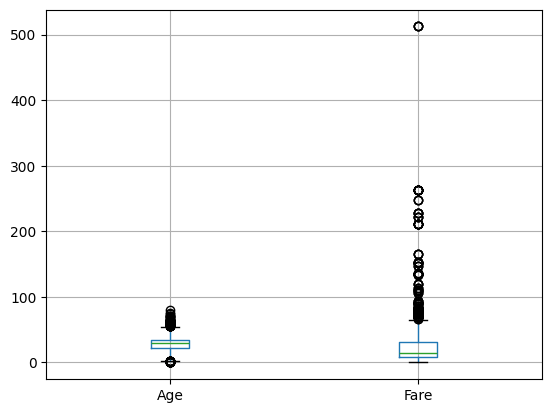

In [223]:
df.boxplot()

<Axes: >

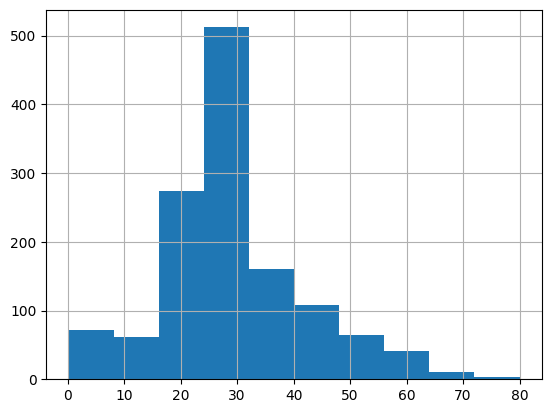

In [224]:
df['Age'].hist()

<Axes: >

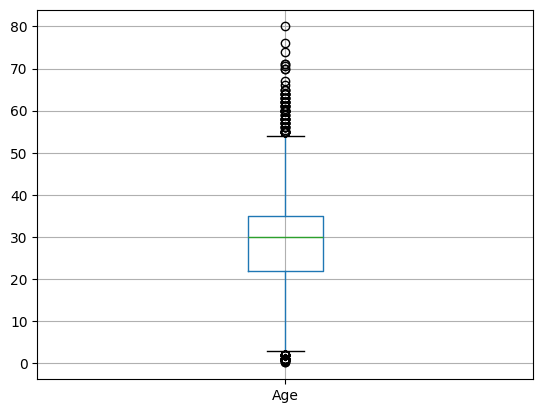

In [226]:
df.boxplot(column='Age')

<Axes: title={'center': 'Age'}, xlabel='Sex'>

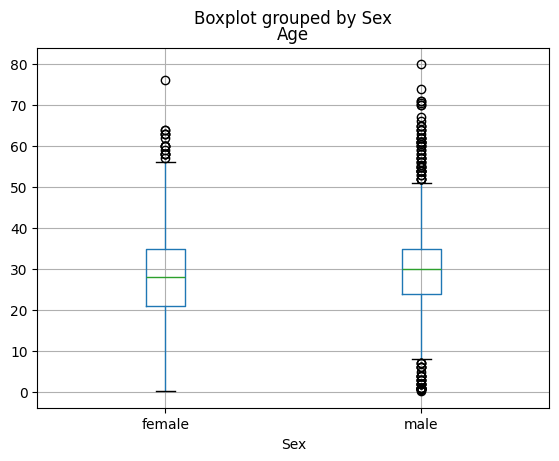

In [227]:
df.boxplot(column='Age', by='Sex')

<Axes: title={'center': 'Age'}, xlabel='Survived'>

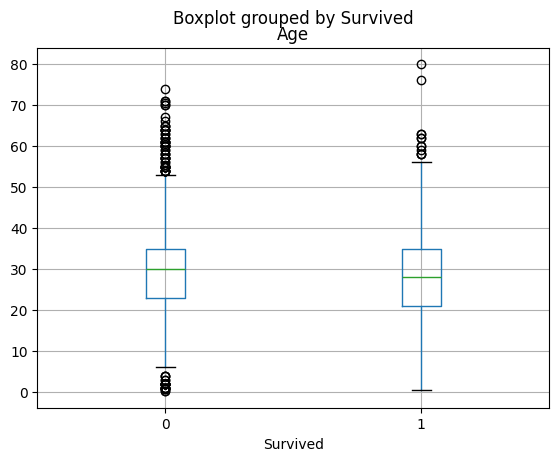

In [228]:
df.boxplot(column='Age', by='Survived')

C:\Users\raine\AppData\Local\Temp\ipykernel_4712\2495380191.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist(column='Age', by='Sex', bins=15)


array([<Axes: title={'center': 'female'}>,
       <Axes: title={'center': 'male'}>], dtype=object)

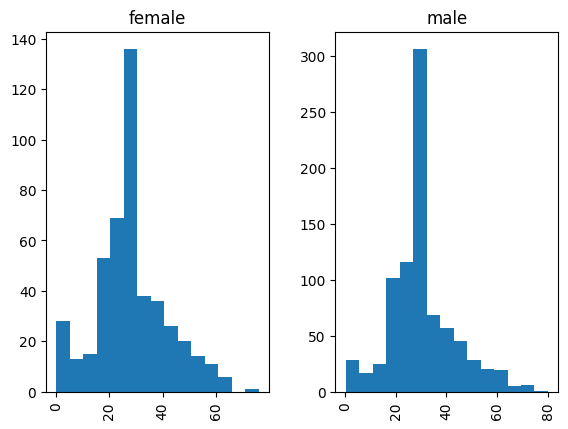

In [232]:
df.hist(column='Age', by='Sex', bins=15)